<a href="https://colab.research.google.com/github/stella1298/AIFFEL_Quest_EPA/blob/master/NLP/NLP04/260908_Quest_Haena.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
!apt-get install -qq -y fonts-nanum > /dev/null
!pip install -q sentencepiece   # Colab 에는 이미 있지만 확인용

In [21]:
#1. Google Drive 연결 및 라이브러리 호출
from google.colab import drive
drive.mount("/content/drive")

import os, re, time
import numpy as np
import matplotlib.pyplot as plt
import sentencepiece as spm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import gc

from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

gc.collect()
torch.cuda.empty_cache()

print("PyTorch:", torch.__version__)
print("SentencePiece:", spm.__version__)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PyTorch: 2.11.0+cu128
SentencePiece: 0.2.2
Device: cuda


In [22]:
#2. 데이터 경로 설정 및 확인
DATA_DIR = "/content/drive/MyDrive/Aiffel_EPA/s2s_translation/datasets"

ko_path = os.path.join(DATA_DIR, "korean-english-park.train.ko")
en_path = os.path.join(DATA_DIR, "korean-english-park.train.en")

if not os.path.exists(ko_path):
    raise FileNotFoundError(f"한국어 파일이 없습니다: {ko_path}")

if not os.path.exists(en_path):
    raise FileNotFoundError(f"영어 파일이 없습니다: {en_path}")

print("한국어 파일:", ko_path)
print("영어 파일:", en_path)
print("한국어 파일 크기:", f"{os.path.getsize(ko_path)/1024/1024:.2f} MB")
print("영어 파일 크기:", f"{os.path.getsize(en_path)/1024/1024:.2f} MB")

한국어 파일: /content/drive/MyDrive/Aiffel_EPA/s2s_translation/datasets/korean-english-park.train.ko
영어 파일: /content/drive/MyDrive/Aiffel_EPA/s2s_translation/datasets/korean-english-park.train.en
한국어 파일 크기: 13.09 MB
영어 파일 크기: 11.43 MB


In [23]:
#3. 한국어·영어 전처리 함수
def preprocess_korean(sentence):
    sentence = sentence.strip()
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r"[^가-힣a-zA-Z0-9?.!,-]+", " ", sentence)
    return re.sub(r"\s+", " ", sentence).strip()

def preprocess_english(sentence):
    sentence = sentence.strip()
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r"[^a-zA-Z0-9?.!,-]+", " ", sentence)
    return re.sub(r"\s+", " ", sentence).strip()

In [24]:
#4. 데이터 읽기 및 문장 쌍 중복 제거
cleaned_corpus = set()

with open(ko_path, encoding="utf-8") as f_ko, open(en_path, encoding="utf-8") as f_en:
    for ko, en in zip(f_ko, f_en):
        ko, en = ko.strip(), en.strip()
        if ko and en:
            cleaned_corpus.add((ko, en))
print("중복 제거 후 문장 쌍:", len(cleaned_corpus))

문장 쌍: 71911
한국어: ['남아프리카인들은 미리암 마케바의 타계를 애도하고 있습니다 .', '취임식을 보려고 왔어요 .', '관계자들은 수니파 반군측이 시아파 사원을 공격한 것으로 생각하고 있다 .']
영어: ['South Africans are mourning the loss of Miriam Makeba', 'I came over especially for the inauguration .', 'Authorities believe Sunni insurgents hit the mosque .']


In [ ]:
#5. 전처리 및 40단어 이하 필터링
kor_corpus, eng_corpus = [], []

for ko, en in cleaned_corpus:
    ko = preprocess_korean(ko)
    en = preprocess_english(en)
    if len(ko.split()) <= 40 and len(en.split()) <= 40:
        kor_corpus.append(ko)
        eng_corpus.append(en)

assert len(kor_corpus) == len(eng_corpus)

print("문장 쌍:", len(kor_corpus))
print("한국어:", kor_corpus[:3])
print("영어:", eng_corpus[:3])

In [25]:
#6. SentencePiece 학습용 파일 생성
#원본 데이터를 덮어쓰지 않고 현재 Colab 작업 공간에 생성
with open("kor_corpus.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(kor_corpus))

with open("eng_corpus.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(eng_corpus))

In [57]:
#7. SentencePiece 학습
#한국어 → ko_spm → Encoder
#영어   → en_spm → Decoder
VOCAB_SIZE = 20000
PAD_ID, BOS_ID, EOS_ID, UNK_ID = 0, 1, 2, 3

spm.SentencePieceTrainer.train(
    input="kor_corpus.txt", model_prefix="ko_spm",
    vocab_size=VOCAB_SIZE, model_type="bpe",
    character_coverage=0.9995,
    pad_id=PAD_ID, bos_id=BOS_ID, eos_id=EOS_ID, unk_id=UNK_ID
)

spm.SentencePieceTrainer.train(
    input="eng_corpus.txt", model_prefix="en_spm",
    vocab_size=VOCAB_SIZE, model_type="bpe",
    character_coverage=1.0,
    pad_id=PAD_ID, bos_id=BOS_ID, eos_id=EOS_ID, unk_id=UNK_ID
)

True

In [58]:
#8. SentencePiece 모델 불러오기
encoder_tokenizer = spm.SentencePieceProcessor()
decoder_tokenizer = spm.SentencePieceProcessor()

encoder_tokenizer.load("ko_spm.model")
decoder_tokenizer.load("en_spm.model")

print("Encoder vocab:", encoder_tokenizer.get_piece_size())
print("Decoder vocab:", decoder_tokenizer.get_piece_size())

Encoder vocab: 20000
Decoder vocab: 20000


In [59]:
#9. Dataset
#MAX_LEN = 50
#BOS/EOS 추가

MAX_LEN = 50

class TranslationDataset(Dataset):
    def __init__(self, kor_corpus, eng_corpus):
        self.kor = kor_corpus
        self.eng = eng_corpus

    def __len__(self):
        return len(self.kor)

    def __getitem__(self, idx):
        src = encoder_tokenizer.encode(self.kor[idx])[:MAX_LEN]
        trg = decoder_tokenizer.encode(self.eng[idx])[:MAX_LEN-1]

        src = src + [PAD_ID] * (MAX_LEN - len(src))
        trg_input = [BOS_ID] + trg
        trg_label = trg + [EOS_ID]

        trg_input += [PAD_ID] * (MAX_LEN - len(trg_input))
        trg_label += [PAD_ID] * (MAX_LEN - len(trg_label))

        return torch.tensor(src), torch.tensor(trg_input), torch.tensor(trg_label)

In [60]:
#10. DataLoader
BATCH_SIZE = 64

dataset = TranslationDataset(kor_corpus, eng_corpus)
train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

src, trg_input, trg_label = next(iter(train_loader))

print("src:", src.shape)
print("trg_input:", trg_input.shape)
print("trg_label:", trg_label.shape)

src: torch.Size([64, 50])
trg_input: torch.Size([64, 50])
trg_label: torch.Size([64, 50])


In [61]:
#11. Encoder
class Encoder(nn.Module):
    def __init__(self, input_dim, embed_dim, hidden_dim, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, embed_dim)
        self.rnn = nn.GRU(embed_dim, hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        embedded = self.dropout(self.embedding(src))
        return self.rnn(embedded)

In [62]:
#12. Bahdanau Attention
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        src_len = encoder_outputs.shape[0]
        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)
        enc = encoder_outputs.permute(1, 0, 2)

        energy = torch.tanh(self.W1(enc) + self.W2(hidden))
        score = self.v(energy).squeeze(2)

        return F.softmax(score, dim=1)

In [63]:
#13. Decoder
class Decoder(nn.Module):
    def __init__(self, output_dim, embed_dim, hidden_dim, attention, dropout=0.1):
        super().__init__()
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, embed_dim)
        self.rnn = nn.GRU(embed_dim + hidden_dim, hidden_dim)
        self.fc_out = nn.Linear(embed_dim + hidden_dim * 2, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, trg_input, hidden, encoder_outputs):
        embedded = self.dropout(self.embedding(trg_input.unsqueeze(0)))

        attn = self.attention(hidden.squeeze(0), encoder_outputs)

        context = torch.bmm(
            attn.unsqueeze(1),
            encoder_outputs.permute(1, 0, 2)
        ).permute(1, 0, 2)

        rnn_input = torch.cat((embedded, context), dim=2)
        output, hidden = self.rnn(rnn_input, hidden)

        output = output.squeeze(0)
        embedded = embedded.squeeze(0)
        context = context.squeeze(0)

        prediction = self.fc_out(
            torch.cat((output, context, embedded), dim=1)
        )

        return prediction, hidden, attn

In [64]:
#14. Seq2Seq + Attention
#Teacher Forcing : 학습 중에는 예측한 단어가 아니라 정답 시퀀스 trg_input의 다음 토큰을 그대로 다음 입력으로 씁니다.
#이를 teacher forcing이라고 해요.
#그래서 디코더의 반복문은 정답 길이만큼 돌고, 예측 결과는 (trg_len, batch_size, output_dim) 텐서 하나로 모입니다.
class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg=None, max_len=50):
        encoder_outputs, hidden = self.encoder(src)

        batch_size = src.shape[1]
        outputs, attentions = [], []

        if trg is not None:
            for t in range(trg.shape[0]):
                output, hidden, attn = self.decoder(
                    trg[t], hidden, encoder_outputs
                )
                outputs.append(output.unsqueeze(0))
                attentions.append(attn.unsqueeze(0))
        else:
            input = torch.full(
                (batch_size,), BOS_ID,
                dtype=torch.long,
                device=self.device
            )

            for _ in range(max_len):
                output, hidden, attn = self.decoder(
                    input, hidden, encoder_outputs
                )

                outputs.append(output.unsqueeze(0))
                attentions.append(attn.unsqueeze(0))

                input = output.argmax(1)

                if (input == EOS_ID).all():
                    break

        return torch.cat(outputs), torch.cat(attentions)

In [65]:
#15. 모델 생성
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

EMBED_DIM = 256
HIDDEN_DIM = 512

encoder = Encoder(
    encoder_tokenizer.get_piece_size(),
    EMBED_DIM, HIDDEN_DIM
)

attention = BahdanauAttention(HIDDEN_DIM)

decoder = Decoder(
    decoder_tokenizer.get_piece_size(),
    EMBED_DIM, HIDDEN_DIM, attention
)

model = Seq2SeqAttention(encoder, decoder, device).to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)

print("모델 생성 완료")
print(model)

Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(20000, 256)
    (rnn): GRU(256, 512)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(20000, 256)
    (rnn): GRU(768, 512)
    (fc_out): Linear(in_features=1280, out_features=20000, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
)


In [66]:
#16. 학습 함수
def train_step(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for src, trg_input, trg_label in tqdm(loader, leave=False):
        src = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)

        optimizer.zero_grad()

        output, _ = model(src, trg_input)

        loss = criterion(
            output.reshape(-1, output.shape[-1]),
            trg_label.reshape(-1)
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
#17. 모델 학습 + 소요시간
#각 Epoch 시간과 전체 학습 시간을 모두 표시

import time

EPOCHS = 10
loss_history = []
start_time = time.time()

for epoch in range(EPOCHS):
    epoch_start = time.time()

    loss = train_step(model, train_loader, optimizer, criterion)
    loss_history.append(loss)

    epoch_time = time.time() - epoch_start
    total_time = time.time() - start_time

    print(f"Epoch {epoch+1:02d} | Loss: {loss:.4f} | "
          f"Epoch 시간: {epoch_time:.1f}초 | 누적: {total_time/60:.1f}분")

total_time = time.time() - start_time
print(f"\n총 학습 시간: {total_time/60:.2f}분 ({total_time:.1f}초)")

  0%|          | 0/1124 [00:00<?, ?it/s]

Epoch 01 | Loss: 5.6437 | Epoch 시간: 570.7초 | 누적: 9.5분


  0%|          | 0/1124 [00:00<?, ?it/s]

Epoch 02 | Loss: 4.3413 | Epoch 시간: 576.4초 | 누적: 19.1분


  0%|          | 0/1124 [00:00<?, ?it/s]

...

  0%|          | 0/1124 [00:00<?, ?it/s]

Epoch 05 | Loss: 2.7461 | Epoch 시간: 577.3초 | 누적: 48.0분


  0%|          | 0/1124 [00:00<?, ?it/s]

Epoch 06 | Loss: 2.4910 | Epoch 시간: 578.1초 | 누적: 57.6분


  0%|          | 0/1124 [00:00<?, ?it/s]

In [52]:
#폰트 설정
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import subprocess
import logging

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

# Linux/Colab 기준 Noto CJK 및 Noto Color Emoji 폰트 설치
subprocess.run(
    ["apt-get", "install", "-y", "fonts-noto-cjk", "fonts-noto-core"], check=False
)

# Noto Sans CJK KR 폰트 경로 설정 (또는 시스템 기본 Noto Sans)
noto_fontpath = "/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc"

try:
    fm.fontManager.addfont(noto_fontpath)
    fontprop = fm.FontProperties(fname=noto_fontpath, size=12)
    plt.rcParams["font.family"] = fontprop.get_name()
except Exception:
    # 폰트 경로가 다를 경우 패밀리 이름으로 직접 지정
    plt.rcParams["font.family"] = "Noto Sans CJK JP"

plt.rcParams["axes.unicode_minus"] = False

# 나눔 폰트 경로 지정 및 적용
fontpath = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
fm.fontManager.addfont(fontpath)                      # 방금 apt 로 설치한 폰트를 matplotlib 캐시에 등록
fontprop = fm.FontProperties(fname=fontpath, size=12)
plt.rcParams["font.family"] = fontprop.get_name()

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

print(f"설정된 폰트: {fontprop.get_name()}")

In [42]:
###폰트 설정
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import logging

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

fontpath = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
fm.fontManager.addfont(fontpath)                      # 방금 apt 로 설치한 폰트를 matplotlib 캐시에 등록
fontprop = fm.FontProperties(fname=fontpath, size=12)
plt.rcParams["font.family"] = fontprop.get_name()
plt.rcParams["axes.unicode_minus"] = False            # 한글 폰트에서 마이너스 기호가 깨지지 않게

print(f"설정된 폰트: {fontprop.get_name()}")

설정된 폰트: NanumBarunGothic


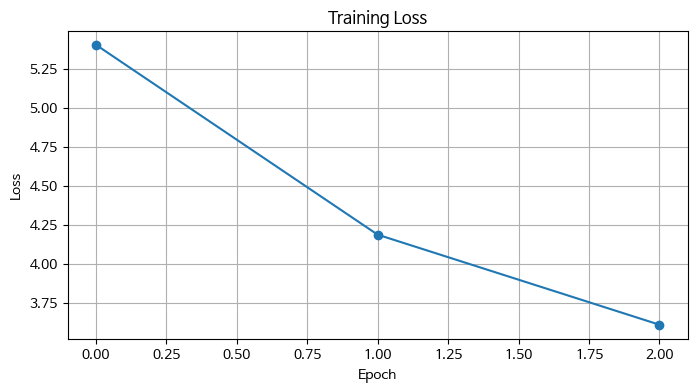

In [53]:
#18. Loss 그래프
plt.figure(figsize=(8, 4))
plt.plot(loss_history, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid()
plt.show()

In [54]:
#19. 번역 함수
def evaluate(sentence):
    model.eval()
    sentence = preprocess_korean(sentence)

    src_ids = encoder_tokenizer.encode(sentence)[:MAX_LEN]
    src_tokens = [encoder_tokenizer.id_to_piece(i) for i in src_ids]

    src_ids += [PAD_ID] * (MAX_LEN - len(src_ids))
    src = torch.tensor(src_ids).unsqueeze(1).to(device)

    with torch.no_grad():
        outputs, attentions = model(src, max_len=MAX_LEN)

    pred_ids = outputs.argmax(2).squeeze(1).tolist()

    if EOS_ID in pred_ids:
        pred_ids = pred_ids[:pred_ids.index(EOS_ID)]

    result = decoder_tokenizer.decode(pred_ids)
    trg_tokens = [decoder_tokenizer.id_to_piece(i) for i in pred_ids]

    attn = attentions.squeeze(1).cpu().numpy()
    attn = attn[:len(pred_ids), :len(src_tokens)]

    return result, src_tokens, trg_tokens, attn

In [55]:
#20. 번역 결과 + Attention 시각화
def translate(sentence):
    result, src_tokens, trg_tokens, attn = evaluate(sentence)

    print("입력 :", sentence)
    print("번역 :", result)

    if not trg_tokens:
        return

    src_labels = [x.replace("▁", " ") for x in src_tokens]
    trg_labels = [x.replace("▁", " ") for x in trg_tokens]

    plt.figure(figsize=(10, 6))
    plt.imshow(attn, aspect="auto", cmap="viridis")
    plt.xticks(range(len(src_labels)), src_labels, rotation=90)
    plt.yticks(range(len(trg_labels)), trg_labels)
    plt.xlabel("Korean")
    plt.ylabel("English")
    plt.title("Bahdanau Attention")
    plt.tight_layout()
    plt.show()

In [ ]:
translate("오바마는 대통령이다.")

In [ ]:
translate("시민들은 도시 속에 산다.")

In [ ]:
translate("커피는 필요 없다.")

In [ ]:
translate("일곱 명의 사망자가 발생했다.")

입력 : 오바마는 대통령이다.
번역 : Obama is the first thing to be president .


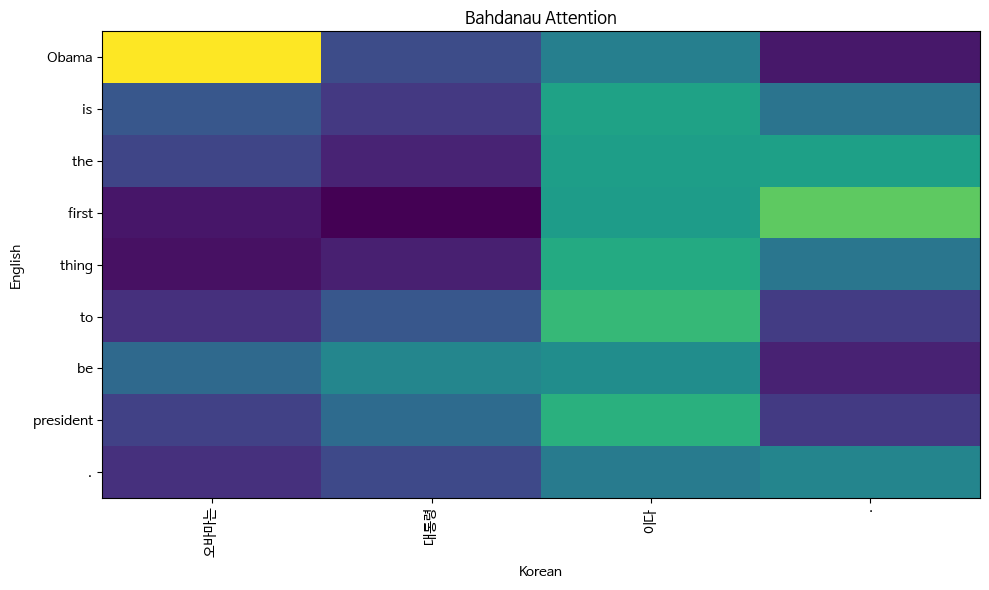

입력 : 시민들은 도시 속에 산다.
번역 : The city streets were running out of the city .


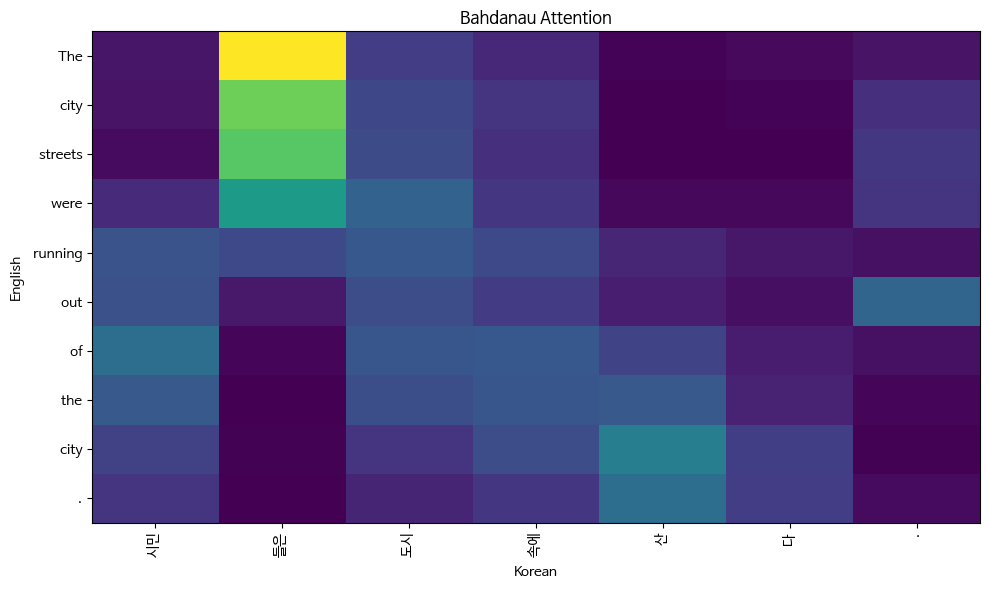

입력 : 커피는 필요 없다.
번역 : coffee coffee is not the coffee .


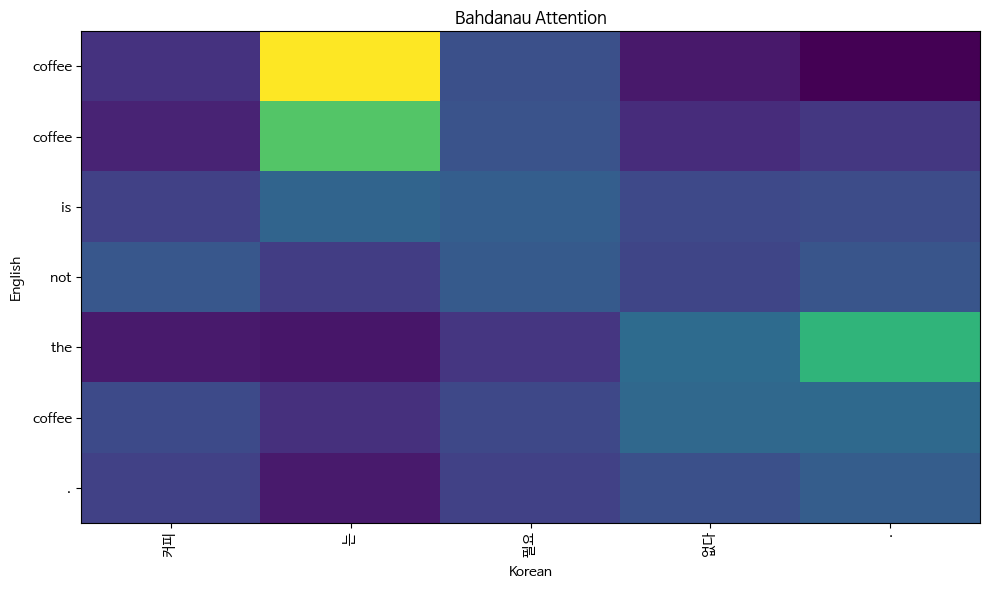

입력 : 일곱 명의 사망자가 발생했다.
번역 : The death toll was killed .


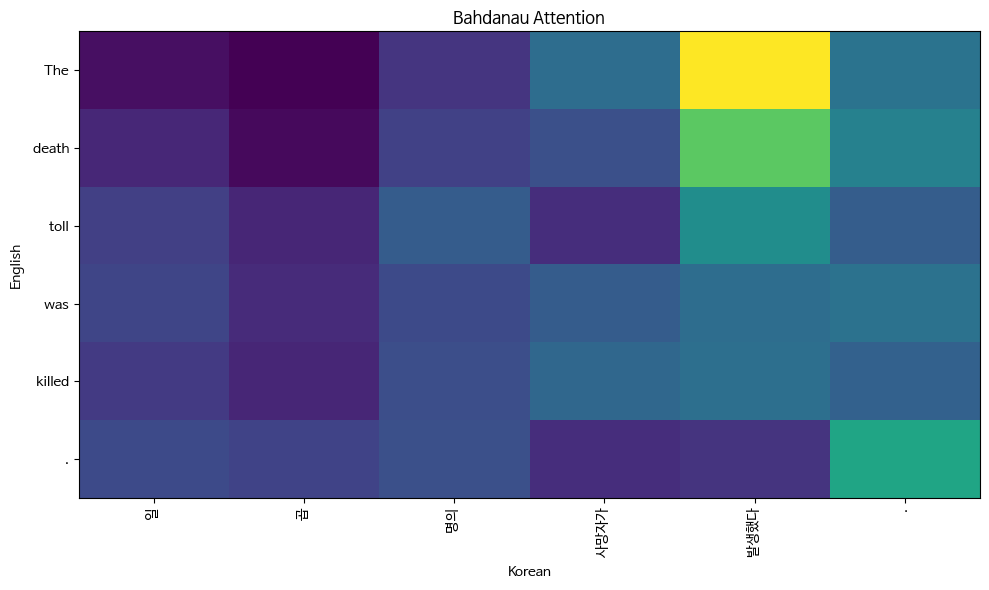

In [56]:
#21. 테스트
test_sentences = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다."
]

for sentence in test_sentences:
    translate(sentence)